# Watching a neural network forget

Companion notebook to [Continual learning: what it is, and what I've learned working with it](https://ihshaish.github.io/blog/ml/continual-learning/).

A neural network trained on a sequence of tasks, one after another, tends to overwrite what it learned earlier. This is *catastrophic forgetting* (McCloskey and Cohen, 1989). The experiment below makes the effect visible on a dataset small enough to run on a laptop in a couple of minutes, then compares three standard responses:

1. **Naive fine-tuning**: keep training the same network on each new task and hope for the best.
2. **Elastic Weight Consolidation (EWC)** (Kirkpatrick et al., 2017): penalise changes to weights that mattered for earlier tasks.
3. **Experience replay**: keep a small buffer of old examples and mix them into training on the new task.

As an upper bound we also train a model **jointly** on all data seen so far, which is what we could do if storage, compute and data access were unlimited.

**The setup.** We use scikit-learn's digits dataset (1,797 images of handwritten digits, 8x8 pixels) and split it into five tasks of two classes each: {0,1}, {2,3}, {4,5}, {6,7}, {8,9}. The model is a small multilayer perceptron with a single 10-way output head, and at test time it is *not* told which task an image came from. This is the **class-incremental** scenario in the taxonomy of van de Ven and Tolias (2019), the hardest of the three standard scenarios and the one closest to how the problem shows up in practice.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

torch.manual_seed(0)
np.random.seed(0)

digits = load_digits()
X = (digits.data / 16.0).astype(np.float32)   # pixel values in [0, 1]
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=0)

TASKS = [(0, 1), (2, 3), (4, 5), (6, 7), (8, 9)]

def task_split(Xa, ya, classes):
    mask = np.isin(ya, classes)
    return torch.tensor(Xa[mask]), torch.tensor(ya[mask])

train_tasks = [task_split(X_train, y_train, c) for c in TASKS]
test_tasks  = [task_split(X_test,  y_test,  c) for c in TASKS]

print("Training samples per task:", [len(t[0]) for t in train_tasks])
print("Test samples per task:    ", [len(t[0]) for t in test_tasks])

Training samples per task: [251, 252, 254, 252, 248]
Test samples per task:     [109, 108, 109, 108, 106]


## Model and training loop

Nothing exotic: a 64-100-100-10 MLP trained with Adam and cross-entropy. `train()` accepts an optional penalty term, which is how EWC will plug in later. After each task we record accuracy on the test split of *every* task, giving an accuracy matrix $R$ where $R_{ij}$ is the accuracy on task $j$ after finishing training on task $i$. Most of what matters in a continual learning experiment can be read off this matrix (Lopez-Paz and Ranzato, 2017).

In [2]:
def make_model():
    return nn.Sequential(
        nn.Linear(64, 100), nn.ReLU(),
        nn.Linear(100, 100), nn.ReLU(),
        nn.Linear(100, 10))

def train(model, Xa, ya, epochs=30, lr=1e-3, batch=32, penalty=None):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        perm = torch.randperm(len(Xa))
        for i in range(0, len(Xa), batch):
            idx = perm[i:i + batch]
            loss = F.cross_entropy(model(Xa[idx]), ya[idx])
            if penalty is not None:
                loss = loss + penalty(model)
            opt.zero_grad()
            loss.backward()
            opt.step()

@torch.no_grad()
def accuracy(model, Xa, ya):
    return (model(Xa).argmax(1) == ya).float().mean().item()

def eval_all(model):
    return [accuracy(model, Xt, yt) for Xt, yt in test_tasks]

## Strategy 1: naive fine-tuning

Train on task 1, then keep training the same network on task 2, and so on. No memory of the past, no protection for old weights.

In [3]:
model = make_model()
R_naive = []
for X_c, y_c in train_tasks:
    train(model, X_c, y_c)
    R_naive.append(eval_all(model))
R_naive = np.array(R_naive)

print("Accuracy on each task after the final one (naive):")
print(np.round(R_naive[-1], 3))

Accuracy on each task after the final one (naive):
[0. 0. 0. 0. 1.]


The pattern is stark: near-perfect accuracy on the most recent pair of digits, and close to zero on everything before it. The gradients from the new task point wherever the new loss surface wants them to, and nothing stops them trampling the weights the old tasks relied on.

## Strategy 2: Elastic Weight Consolidation

EWC (Kirkpatrick et al., 2017) estimates, for each weight, how much earlier tasks care about it, using the diagonal of the Fisher information matrix, and adds a quadratic penalty that anchors important weights near the values they had when the earlier task finished:

$$\mathcal{L}(\theta) = \mathcal{L}_{\text{new}}(\theta) + \sum_{t} \frac{\lambda}{2} \sum_i F_i^{(t)} \, (\theta_i - \theta_i^{(t)*})^2$$

where $F^{(t)}$ is the Fisher diagonal for task $t$ and $\theta^{(t)*}$ the weights at the end of that task.

In [4]:
def fisher_diagonal(model, Xa, ya):
    fisher = [torch.zeros_like(p) for p in model.parameters()]
    for i in range(len(Xa)):
        model.zero_grad()
        log_p = F.log_softmax(model(Xa[i:i + 1]), dim=1)[0, ya[i]]
        log_p.backward()
        for f, p in zip(fisher, model.parameters()):
            f += p.grad.detach() ** 2
    model.zero_grad()
    return [f / len(Xa) for f in fisher]

class EWC:
    def __init__(self, lam=5000.0):
        self.lam = lam
        self.anchors = []   # list of (fisher, weights_star) per finished task

    def add_task(self, model, Xa, ya):
        star = [p.detach().clone() for p in model.parameters()]
        self.anchors.append((fisher_diagonal(model, Xa, ya), star))

    def penalty(self, model):
        if not self.anchors:
            return torch.tensor(0.0)
        total = 0.0
        for fisher, star in self.anchors:
            for f, p, ps in zip(fisher, model.parameters(), star):
                total = total + (f * (p - ps) ** 2).sum()
        return self.lam / 2 * total

model = make_model()
ewc = EWC(lam=5000.0)
R_ewc = []
for X_c, y_c in train_tasks:
    train(model, X_c, y_c, penalty=ewc.penalty)
    ewc.add_task(model, X_c, y_c)
    R_ewc.append(eval_all(model))
R_ewc = np.array(R_ewc)

print("Accuracy on each task after the final one (EWC):")
print(np.round(R_ewc[-1], 3))

Accuracy on each task after the final one (EWC):
[0.    0.    0.    0.    0.934]


EWC gives us essentially nothing here: on average it ends level with naive fine-tuning. This is not a bug in the implementation. Regularisation methods are known to struggle in the class-incremental scenario, where the model must also learn to *discriminate between classes it never saw together*. Protecting old weights does nothing to teach the output layer that a 0 and a 7 need to be separated when no batch ever contained both. van de Ven and Tolias (2019) document this failure mode systematically; it is one of the more useful negative results in the field, because it explains why published results on task-incremental benchmarks can evaporate the moment the task label is taken away.

## Strategy 3: experience replay

Keep a small buffer of examples from previous tasks (here 20 per class, so at most 200 images in total, about 16% of the training set) and mix it into the training data for each new task.

In [5]:
BUFFER_PER_CLASS = 20

model = make_model()
buffer_X, buffer_y = [], []
R_replay = []
for (X_c, y_c), classes in zip(train_tasks, TASKS):
    if buffer_X:
        X_mix = torch.cat([X_c] + buffer_X)
        y_mix = torch.cat([y_c] + buffer_y)
    else:
        X_mix, y_mix = X_c, y_c
    train(model, X_mix, y_mix)
    for c in classes:
        idx = (y_c == c).nonzero().flatten()[:BUFFER_PER_CLASS]
        buffer_X.append(X_c[idx])
        buffer_y.append(y_c[idx])
    R_replay.append(eval_all(model))
R_replay = np.array(R_replay)

print("Accuracy on each task after the final one (replay):")
print(np.round(R_replay[-1], 3))

Accuracy on each task after the final one (replay):
[0.917 0.889 0.927 0.935 0.962]


## Upper bound: joint training

At each stage, retrain from scratch on all data seen so far. This is what continual learning methods are trying to approximate without the luxury of keeping everything.

In [6]:
R_joint = []
for t in range(len(TASKS)):
    model = make_model()
    X_all = torch.cat([train_tasks[i][0] for i in range(t + 1)])
    y_all = torch.cat([train_tasks[i][1] for i in range(t + 1)])
    train(model, X_all, y_all)
    R_joint.append(eval_all(model))
R_joint = np.array(R_joint)

print("Accuracy on each task after the final stage (joint):")
print(np.round(R_joint[-1], 3))

Accuracy on each task after the final stage (joint):
[0.982 0.981 0.963 0.991 0.953]


## Results

Two standard metrics, both computed from the accuracy matrix (Lopez-Paz and Ranzato, 2017; Chaudhry et al., 2018):

- **Average accuracy**: mean accuracy over all tasks after training on the last one.
- **Forgetting**: for each task, the gap between the best accuracy it ever had and its accuracy at the end, averaged over tasks. Zero means nothing learned was lost.

In [7]:
def avg_accuracy(R):
    return R[-1].mean()

def forgetting(R):
    gaps = [R[:, j].max() - R[-1, j] for j in range(R.shape[1] - 1)]
    return float(np.mean(gaps))

strategies = [
    ("Naive fine-tuning", R_naive),
    ("EWC",               R_ewc),
    ("Replay",            R_replay),
    ("Joint (upper bound)", R_joint),
]

print(f"{'Strategy':<22}{'Avg accuracy':>14}{'Forgetting':>12}")
for name, R in strategies:
    print(f"{name:<22}{avg_accuracy(R):>13.1%}{forgetting(R):>11.1%}")

Strategy                Avg accuracy  Forgetting
Naive fine-tuning             20.0%      99.8%
EWC                           18.7%      99.8%
Replay                        92.6%       7.4%
Joint (upper bound)           97.4%       1.1%


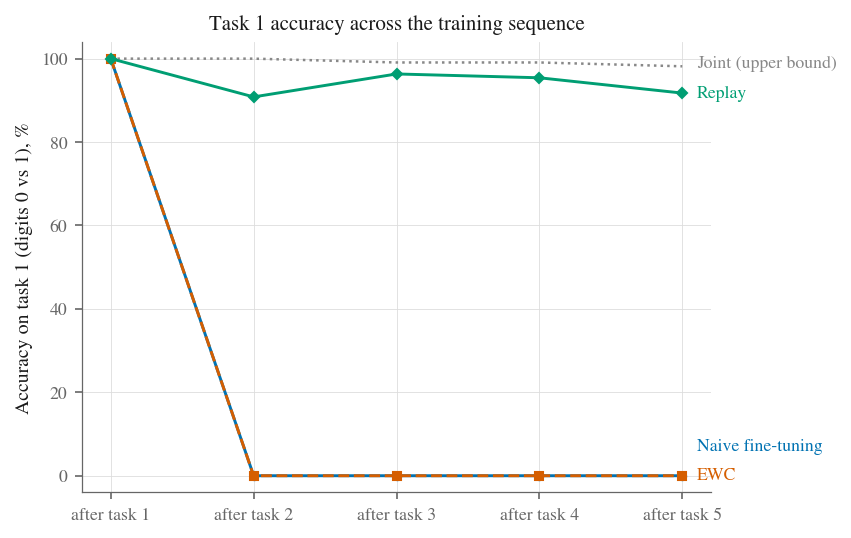

In [8]:
import os
import matplotlib.pyplot as plt

os.makedirs("figs", exist_ok=True)

# Figure style: serif, muted colours, linestyle as second encoding, recessive grid
plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 9.5, "axes.labelsize": 9.5, "axes.titlesize": 10,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "text.color": "#1a1a1a", "axes.labelcolor": "#1a1a1a",
    "xtick.color": "#666666", "ytick.color": "#666666",
    "axes.edgecolor": "#666666", "axes.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#dddddd", "grid.linewidth": 0.4,
    "axes.axisbelow": True, "legend.frameon": False,
})

STYLE = {
    "Naive fine-tuning":   dict(color="#0072B2", ls="-",  marker="o"),
    "EWC":                 dict(color="#D55E00", ls="--", marker="s"),
    "Replay":              dict(color="#009E73", ls="-",  marker="D"),
    "Joint (upper bound)": dict(color="#888888", ls=":",  marker=""),
}

# Accuracy on the first task as training moves through the sequence
stages = np.arange(1, 6)
fig, ax = plt.subplots(figsize=(6.6, 3.9))
s = STYLE["Joint (upper bound)"]
ax.plot(stages, R_joint[:, 0] * 100, ls=s["ls"], lw=1.2, color=s["color"], zorder=1)
for name, R in [("Naive fine-tuning", R_naive), ("EWC", R_ewc), ("Replay", R_replay)]:
    s = STYLE[name]
    ax.plot(stages, R[:, 0] * 100, ls=s["ls"], marker=s["marker"], ms=3.5,
            lw=1.4, color=s["color"], zorder=2)

# direct labels at the right edge, nudged apart if they collide
finals = sorted(
    [(R[-1, 0] * 100, n) for n, R in
     [("Naive fine-tuning", R_naive), ("EWC", R_ewc), ("Replay", R_replay),
      ("Joint (upper bound)", R_joint)]])
placed = []
for val, name in finals:
    ypos = val
    if placed and ypos - placed[-1] < 7:
        ypos = placed[-1] + 7
    placed.append(ypos)
    ax.annotate(name, (5, ypos), xytext=(7, 0), textcoords="offset points",
                va="center", fontsize=8.5, color=STYLE[name]["color"],
                annotation_clip=False)

ax.set_xticks(stages)
ax.set_xticklabels([f"after task {i}" for i in stages])
ax.set_ylim(-4, 104)
ax.set_ylabel("Accuracy on task 1 (digits 0 vs 1), %")
ax.set_title("Task 1 accuracy across the training sequence")
fig.subplots_adjust(right=0.76)
fig.savefig("figs/forgetting_curve.png")
plt.show()

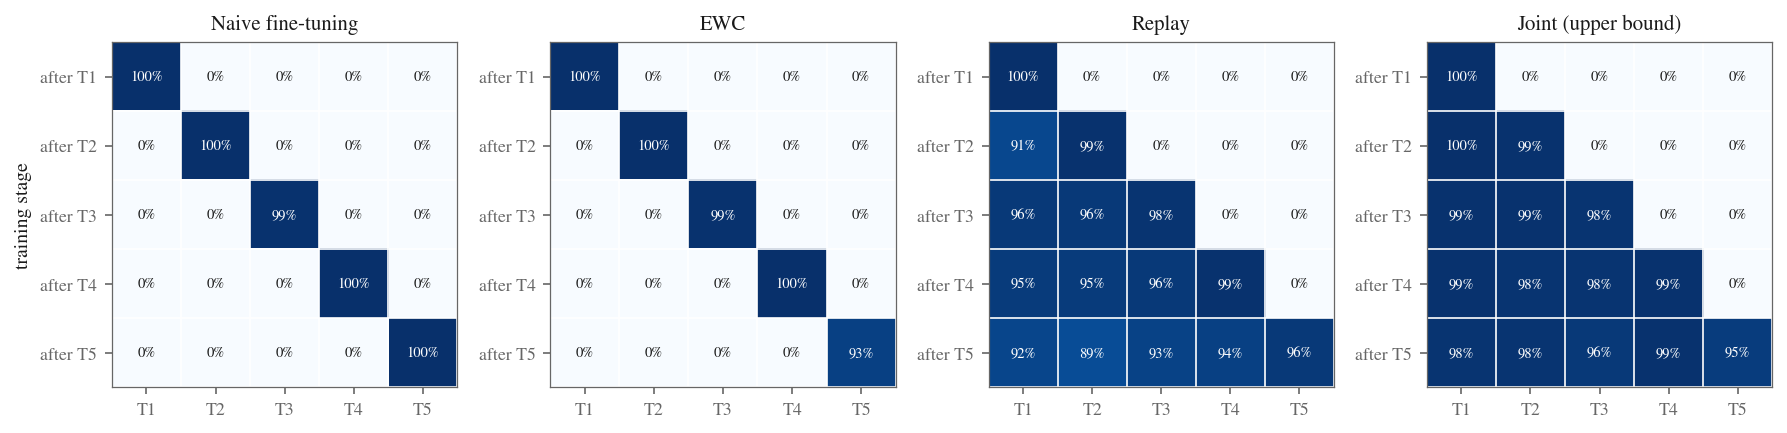

In [9]:
# Full accuracy matrices: rows = after training task i, columns = tested on task j
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for ax, (name, R) in zip(axes, strategies):
    ax.imshow(R, cmap="Blues", vmin=0, vmax=1)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f"{R[i, j]:.0%}", ha="center", va="center", fontsize=7,
                    color="white" if R[i, j] > 0.6 else "#1a1a1a")
    # thin white separators between cells
    ax.set_xticks(np.arange(-0.5, 5), minor=True)
    ax.set_yticks(np.arange(-0.5, 5), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.8)
    ax.tick_params(which="minor", length=0)
    ax.set_title(name)
    ax.set_xticks(range(5)); ax.set_xticklabels([f"T{j+1}" for j in range(5)])
    ax.set_yticks(range(5)); ax.set_yticklabels([f"after T{i+1}" for i in range(5)])
    ax.grid(False)
    for side in ("top", "right"):
        ax.spines[side].set_visible(True)
axes[0].set_ylabel("training stage")
fig.tight_layout()
fig.savefig("figs/accuracy_matrices.png")
plt.show()

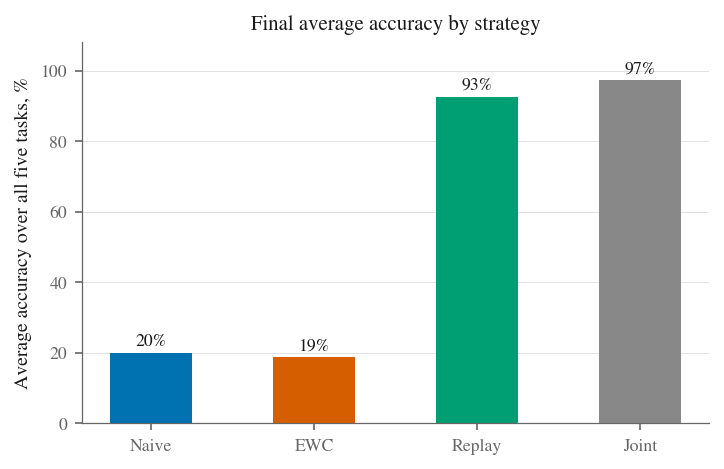

In [10]:
# Final average accuracy, side by side
fig, ax = plt.subplots(figsize=(5.4, 3.3))
names = [n for n, _ in strategies]
vals = [avg_accuracy(R) * 100 for _, R in strategies]
ax.bar(range(len(names)), vals, width=0.5,
       color=[STYLE[n]["color"] for n in names], edgecolor="none")
for i, v in enumerate(vals):
    ax.text(i, v + 2, f"{v:.0f}%", ha="center", fontsize=8.5, color="#1a1a1a")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(["Naive", "EWC", "Replay", "Joint"])
ax.set_ylim(0, 108)
ax.set_ylabel("Average accuracy over all five tasks, %")
ax.set_title("Final average accuracy by strategy")
ax.grid(axis="x")
fig.savefig("figs/final_accuracy.png")
plt.show()

## What to take from this

- **Forgetting is not gradual decay.** Accuracy on old tasks does not drift down politely; it collapses within a task or two of the data disappearing.
- **A small memory goes a long way.** Replay with 200 stored images recovers most of the gap to joint training. This is the single most reliable finding in the empirical literature, and it is why replay (in some form) is the default baseline any new method has to beat.
- **Method rankings depend on the scenario.** EWC looks respectable on task-incremental benchmarks and falls over in the class-incremental setting used here. Always check which scenario a paper evaluates before importing its conclusions.

To go further with proper tooling (bigger benchmarks, more strategies, correct metric implementations), see [Avalanche](https://avalanche.continualai.org/), the continual learning library maintained by ContinualAI.

### References

- McCloskey, M. and Cohen, N. J. (1989). Catastrophic interference in connectionist networks. *Psychology of Learning and Motivation*, 24.
- Kirkpatrick, J. et al. (2017). Overcoming catastrophic forgetting in neural networks. *PNAS*, 114(13). [arXiv:1612.00796](https://arxiv.org/abs/1612.00796)
- Lopez-Paz, D. and Ranzato, M. (2017). Gradient Episodic Memory for continual learning. *NeurIPS*. [arXiv:1706.08840](https://arxiv.org/abs/1706.08840)
- Chaudhry, A. et al. (2018). Riemannian walk for incremental learning. *ECCV*. [arXiv:1801.10112](https://arxiv.org/abs/1801.10112)
- van de Ven, G. M. and Tolias, A. S. (2019). Three scenarios for continual learning. [arXiv:1904.07734](https://arxiv.org/abs/1904.07734)